Before starting the project, I import the Python libraries that will be used throughout the analysis and suppress repeated deprecation warnings so the notebook output stays clean and easier to read. These libraries are needed for data loading, visualization, and pattern-mining computations.

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore", category=DeprecationWarning)

Step 1: Load all five dataset files from the dataset folder and verify that they were loaded correctly by printing their shapes and the first few rows.

In [25]:
aisles = pd.read_csv("dataset/aisles.csv")
departments = pd.read_csv("dataset/departments.csv")
order_products_train = pd.read_csv("dataset/order_products__train.csv")
orders = pd.read_csv("dataset/orders.csv")
products = pd.read_csv("dataset/products.csv")

print("aisles shape:", aisles.shape)
print("departments shape:", departments.shape)
print("order_products_train shape:", order_products_train.shape)
print("orders shape:", orders.shape)
print("products shape:", products.shape)

print("\nAisles:")
display(aisles.head())

print("\nDepartments:")
display(departments.head())

print("\nOrder Products Train:")
display(order_products_train.head())

print("\nOrders:")
display(orders.head())

print("\nProducts:")
display(products.head())

aisles shape: (134, 2)
departments shape: (21, 2)
order_products_train shape: (1384617, 4)
orders shape: (2484848, 7)
products shape: (49688, 4)

Aisles:


,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars
3,4,instant foods
4,5,marinades meat preparation



Departments:


,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol



Order Products Train:


,order_id,product_id,add_to_cart_order,reordered
0,1,49302,1,1
1,1,11109,2,1
2,1,10246,3,0
3,1,49683,4,0
4,1,43633,5,1



Orders:


,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1.0,prior,1.0,2.0,8.0,NaN
1,2398795,1.0,prior,2.0,3.0,7.0,15.0
2,473747,1.0,prior,3.0,3.0,12.0,21.0
3,2254736,1.0,prior,4.0,4.0,7.0,29.0
4,431534,1.0,prior,5.0,4.0,15.0,28.0



Products:


,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


All five dataset files were loaded successfully from the dataset folder. The printed previews confirm that each file has the expected structure: aisles contains aisle IDs and names, departments contains department IDs and names, products links products to aisles and departments, orders contains order-level information, and order_products_train contains the products included in each training order. This confirms the data is ready for the next step, where we will identify the Produce department and build the Produce-specific subset.

Step 2: Identify the Produce department in the metadata and confirm its department_id so we can use it to filter the products in the next step.

In [26]:
produce_row = departments[departments["department"].str.lower() == "produce"]

display(produce_row)

produce_department_id = produce_row.iloc[0]["department_id"]
print("Produce department_id:", produce_department_id)

,department_id,department
3,4,produce


Produce department_id: 4


From the departments metadata, the Produce department was identified successfully. The output shows that Produce has department_id = 4, so this ID will be used in the next step to filter the products table and keep only the products that belong to the Produce department.

Step 3: Filter the products table to keep only the products in the Produce department, then join with the aisles table so we can see each Produce product together with its aisle information.

In [27]:
produce_products = products[products["department_id"] == produce_department_id].copy()

produce_products = produce_products.merge(
    aisles,
    on="aisle_id",
    how="left"
)

print("Produce products shape:", produce_products.shape)
display(produce_products.head())

Produce products shape: (1684, 5)


,product_id,product_name,aisle_id,department_id,aisle
0,31,White Pearl Onions,123,4,packaged vegetables fruits
1,43,Organic Clementines,123,4,packaged vegetables fruits
2,45,European Cucumber,83,4,fresh vegetables
3,66,European Style Spring Mix,123,4,packaged vegetables fruits
4,89,Yogurt Fruit Dip Sliced Apples,123,4,packaged vegetables fruits


The products table was filtered successfully to keep only the products in the Produce department (department_id = 4). After joining with the aisles table, the resulting produce_products table contains 1,684 Produce products, and each product now includes its aisle information. This gives us the Produce-specific product list that we will use in the next step to connect products with actual customer orders.

Step 4: Join the Produce products with order_products_train and then with orders to build the main Produce transaction table that contains product, aisle, and order information together.

In [28]:
produce_order_products = order_products_train.merge(
    produce_products,
    on="product_id",
    how="inner"
)

train_orders = orders[orders["eval_set"].astype(str).str.strip().str.lower() == "train"].copy()

produce_order_products["order_id"] = pd.to_numeric(
    produce_order_products["order_id"], errors="coerce"
).astype("Int64")

train_orders["order_id"] = pd.to_numeric(
    train_orders["order_id"], errors="coerce"
).astype("Int64")

produce_orders = produce_order_products.merge(
    train_orders,
    on="order_id",
    how="left"
)

print("Produce order-products shape:", produce_order_products.shape)
print("Train orders shape:", train_orders.shape)
print("Produce orders shape:", produce_orders.shape)
print("Missing user_id after merge:", int(produce_orders["user_id"].isna().sum()))

display(produce_orders.head())

Produce order-products shape: (409087, 8)
Train orders shape: (95094, 7)
Produce orders shape: (409087, 14)
Missing user_id after merge: 113150


,order_id,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id,aisle,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,1,10246,3,0,Organic Celery Hearts,83,4,fresh vegetables,112108.0,train,4.0,4.0,10.0,9.0
1,1,49683,4,0,Cucumber Kirby,83,4,fresh vegetables,112108.0,train,4.0,4.0,10.0,9.0
2,1,13176,6,0,Bag of Organic Bananas,24,4,fresh fruits,112108.0,train,4.0,4.0,10.0,9.0
3,1,47209,7,0,Organic Hass Avocado,24,4,fresh fruits,112108.0,train,4.0,4.0,10.0,9.0
4,36,43086,4,1,Super Greens Salad,123,4,packaged vegetables fruits,79431.0,train,23.0,6.0,18.0,30.0


The Produce products were joined successfully with order_products__train and then with the orders table to build the main Produce transaction table. The intermediate produce_order_products table contains 409,087 Produce product rows from the training orders, and the final produce_orders table also contains 409,087 rows with product, aisle, and order information combined. The merge worked correctly because the number of missing user_id values after the merge is 0, so this table is now ready for the statistical analysis steps.

Step 5: Statistical Analysis
In this section, I will perform 3 statistical analyses on the Produce department data.

*   Step 5.1 identifies which aisles belong to the Produce department and counts how many Produce products are in each aisle, including the percentage share of each aisle.

*   Step 5.2 finds the top 10 most frequently purchased Produce products in the training orders, including the percentage share of each product within the top 10 list.

*   Step 5.3 analyzes when Produce purchases happen by examining the purchase counts by day of week and by hour of day.

Step 5.1: Analyze and visualize which aisles belong to the Produce department and how many Produce products are in each aisle, including the percentage share of each aisle.

Number of Produce aisles: 5


,aisle,product_count
4,packaged vegetables fruits,615
2,fresh vegetables,569
0,fresh fruits,382
1,fresh herbs,86
3,packaged produce,32


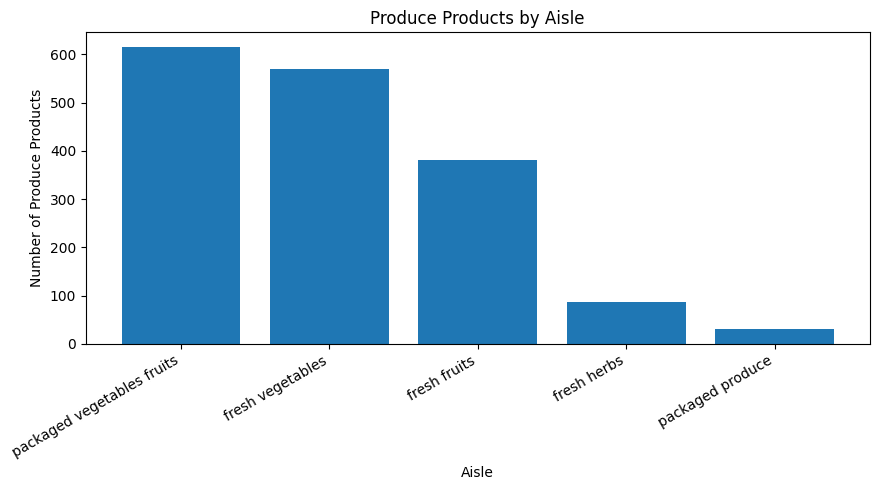

Produce aisle distribution:
packaged vegetables fruits: 615 products (36.52%)
fresh vegetables: 569 products (33.79%)
fresh fruits: 382 products (22.68%)
fresh herbs: 86 products (5.11%)
packaged produce: 32 products (1.9%)


In [29]:
produce_aisle_counts = (
    produce_products.groupby("aisle")["product_id"]
    .count()
    .reset_index(name="product_count")
    .sort_values("product_count", ascending=False)
)

print("Number of Produce aisles:", produce_aisle_counts.shape[0])
display(produce_aisle_counts)

plt.figure(figsize=(9, 5))
plt.bar(produce_aisle_counts["aisle"], produce_aisle_counts["product_count"])

plt.title("Produce Products by Aisle")
plt.xlabel("Aisle")
plt.ylabel("Number of Produce Products")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

produce_aisle_counts["percentage"] = (
    produce_aisle_counts["product_count"] / produce_aisle_counts["product_count"].sum() * 100
).round(2)

print("Produce aisle distribution:")
for _, row in produce_aisle_counts.iterrows():
    print(f"{row['aisle']}: {row['product_count']} products ({row['percentage']}%)")

The bar chart and percentage summary show that Produce products are concentrated mainly in a few major aisles. Packaged vegetables fruits contains 615 products (36.52%), and fresh vegetables contains 569 products (33.79%), making these the two largest Produce aisles. Fresh fruits is also important with 382 products (22.68%), while fresh herbs and packaged produce account for much smaller shares. This confirms that most Produce products are grouped into the main vegetables and fruits aisles.

Step 5.2: Analyze and visualize the top 10 most frequently purchased Produce products in the training orders, including the percentage share of each product within the top 10 list.

,product_name,purchase_count
105,Banana,18726
99,Bag of Organic Bananas,15480
1078,Organic Strawberries,10894
766,Organic Baby Spinach,9784
608,Large Lemon,8135
752,Organic Avocado,7409
903,Organic Hass Avocado,7293
1374,Strawberries,6494
632,Limes,6033
1017,Organic Raspberries,5546


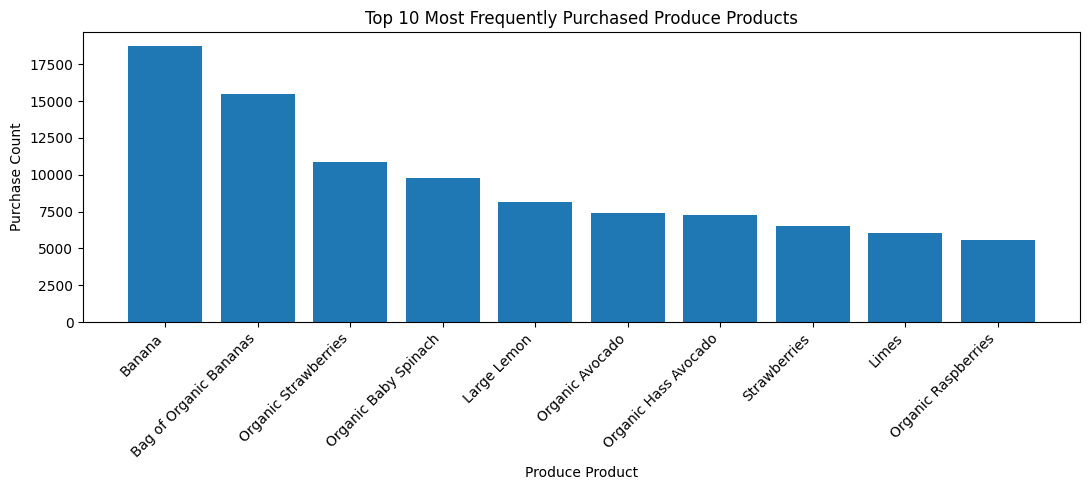

Top 10 Produce product distribution:
Banana: 18726 purchases (19.55%)
Bag of Organic Bananas: 15480 purchases (16.16%)
Organic Strawberries: 10894 purchases (11.37%)
Organic Baby Spinach: 9784 purchases (10.21%)
Large Lemon: 8135 purchases (8.49%)
Organic Avocado: 7409 purchases (7.73%)
Organic Hass Avocado: 7293 purchases (7.61%)
Strawberries: 6494 purchases (6.78%)
Limes: 6033 purchases (6.3%)
Organic Raspberries: 5546 purchases (5.79%)


In [30]:
top_produce_products = (
    produce_orders.groupby("product_name")["order_id"]
    .count()
    .reset_index(name="purchase_count")
    .sort_values("purchase_count", ascending=False)
    .head(10)
)

display(top_produce_products)

plt.figure(figsize=(11, 5))
plt.bar(top_produce_products["product_name"], top_produce_products["purchase_count"])

plt.title("Top 10 Most Frequently Purchased Produce Products")
plt.xlabel("Produce Product")
plt.ylabel("Purchase Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

top_produce_products["percentage"] = (
    top_produce_products["purchase_count"] / top_produce_products["purchase_count"].sum() * 100
).round(2)

print("Top 10 Produce product distribution:")
for _, row in top_produce_products.iterrows():
    print(f"{row['product_name']}: {row['purchase_count']} purchases ({row['percentage']}%)")

The bar chart and percentage summary show that Banana is the most frequently purchased Produce product with 18,726 purchases (19.55% of the top 10 total), followed by Bag of Organic Bananas with 15,480 purchases (16.16%). Together, these two products make up a large share of the top 10 Produce purchases. Other major Produce products include Organic Strawberries, Organic Baby Spinach, Large Lemon, and avocado products. This confirms that Produce purchases are dominated by a small group of very popular everyday items.

Step 5.3: Display and visualize Produce purchase counts by day of week and by hour of day to better show when Produce buying activity is highest.

Produce purchases by day of week:


,order_dow,produce_purchase_count
0,0.0,75490
1,1.0,44138
2,2.0,33110
3,3.0,30616
4,4.0,31272
5,5.0,36451
6,6.0,44860


Produce purchases by hour of day:


,order_hour_of_day,produce_purchase_count
0,0.0,1972
1,1.0,1217
2,2.0,691
3,3.0,491
4,4.0,430
5,5.0,823
6,6.0,2459
7,7.0,8014
8,8.0,14772
9,9.0,20249


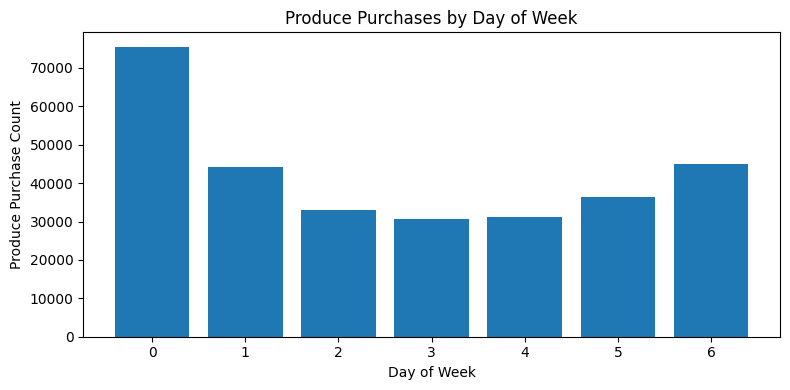

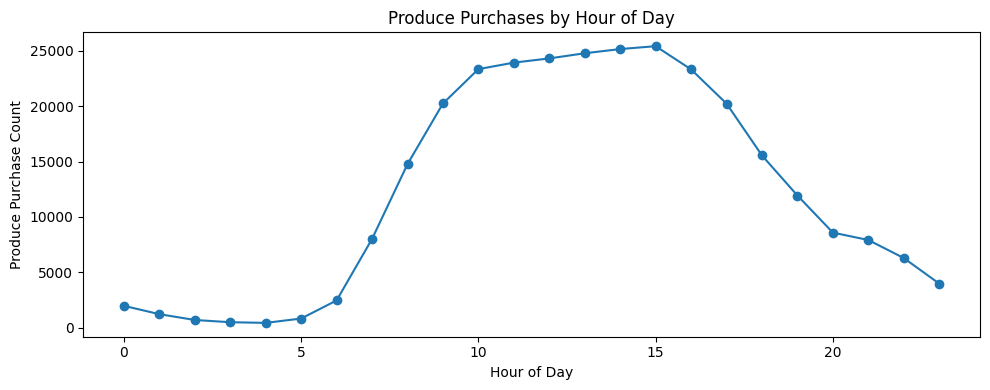

In [31]:
produce_by_day = (
    produce_orders.groupby("order_dow")["order_id"]
    .count()
    .reset_index(name="produce_purchase_count")
    .sort_values("order_dow")
)

produce_by_hour = (
    produce_orders.groupby("order_hour_of_day")["order_id"]
    .count()
    .reset_index(name="produce_purchase_count")
    .sort_values("order_hour_of_day")
)

print("Produce purchases by day of week:")
display(produce_by_day)

print("Produce purchases by hour of day:")
display(produce_by_hour)

plt.figure(figsize=(8, 4))
plt.bar(produce_by_day["order_dow"], produce_by_day["produce_purchase_count"])

plt.title("Produce Purchases by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Produce Purchase Count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(produce_by_hour["order_hour_of_day"], produce_by_hour["produce_purchase_count"], marker="o")

plt.title("Produce Purchases by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Produce Purchase Count")
plt.tight_layout()
plt.show()

The tables and charts show clear timing patterns for Produce purchases. By day of week, Produce purchases are highest on day 0, followed by day 1 and day 6, while the middle days of the week have lower activity. By hour of day, Produce purchases are very low during the late night and early morning hours, then rise quickly after 7:00, remain high from late morning through the afternoon, and peak around 14:00–15:00 before gradually decreasing into the evening. Together, the counts and charts confirm that Produce buying is concentrated both on certain days and during normal daytime shopping hours.

Step 6: Pattern Mining Analysis
In this section, I will perform 3 pattern-mining analyses on the Produce department data.


*   Step 6.1 finds frequent Produce product pairs that appear together in the same order and computes their support count, support, and confidence.

*   Step 6.2 analyzes Produce aisle-to-aisle association patterns to identify which Produce aisle categories tend to appear together in the same orders.

*   Step 6.3 analyzes cross-department association patterns involving Produce to identify which other departments most often appear together with Produce in the same order.

Step 6.1: Find frequent Produce product-to-product patterns by treating each order as a basket of Produce products and using the FP-Growth algorithm to mine frequent itemsets and association rules. This analysis focuses on relationships between individual Produce products. For the strongest one-to-one product rules, compute the support count, support, and confidence to identify which Produce products tend to appear together in the same orders.

In [32]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth, association_rules

produce_baskets = (
    produce_orders.groupby("order_id")["product_name"]
    .apply(lambda x: sorted(set(x)))
    .tolist()
)

num_baskets = len(produce_baskets)
print("Number of Produce baskets:", num_baskets)

te = TransactionEncoder()
te_array = te.fit(produce_baskets).transform(produce_baskets)
produce_basket_df = pd.DataFrame(te_array, columns=te.columns_)

min_support_value = 500 / num_baskets
min_confidence_value = 0.10

frequent_itemsets = fpgrowth(
    produce_basket_df,
    min_support=min_support_value,
    use_colnames=True
)

frequent_itemsets["support_count"] = (frequent_itemsets["support"] * num_baskets).round().astype(int)
frequent_itemsets["itemset_size"] = frequent_itemsets["itemsets"].apply(len)

rules_df = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=min_confidence_value
)

rules_df = rules_df[
    (rules_df["antecedents"].apply(len) == 1) &
    (rules_df["consequents"].apply(len) == 1)
].copy()

rules_df["item_A"] = rules_df["antecedents"].apply(lambda x: next(iter(x)))
rules_df["item_B"] = rules_df["consequents"].apply(lambda x: next(iter(x)))
rules_df["rule"] = rules_df["item_A"] + " -> " + rules_df["item_B"]
rules_df["support_count"] = (rules_df["support"] * num_baskets).round().astype(int)

rules_df = rules_df[
    (rules_df["support_count"] >= 500) &
    (rules_df["confidence"] >= 0.10)
].copy()

rules_df = rules_df[
    ["rule", "item_A", "item_B", "support_count", "support", "confidence"]
].sort_values(
    ["support_count", "confidence"],
    ascending=[False, False]
)

rules_df["support"] = rules_df["support"].round(4)
rules_df["confidence"] = rules_df["confidence"].round(4)

print("Number of frequent itemsets:", len(frequent_itemsets))
print("Number of rules after filtering:", len(rules_df))
display(rules_df.head(20))

Number of Produce baskets: 96927
Number of frequent itemsets: 345
Number of rules after filtering: 217


,rule,item_A,item_B,support_count,support,confidence
102,Organic Strawberries -> Bag of Organic Bananas,Organic Strawberries,Bag of Organic Bananas,3074,0.0317,0.2822
101,Bag of Organic Bananas -> Organic Strawberries,Bag of Organic Bananas,Organic Strawberries,3074,0.0317,0.1986
0,Organic Hass Avocado -> Bag of Organic Bananas,Organic Hass Avocado,Bag of Organic Bananas,2420,0.0250,0.3318
1,Bag of Organic Bananas -> Organic Hass Avocado,Bag of Organic Bananas,Organic Hass Avocado,2420,0.0250,0.1563
143,Organic Baby Spinach -> Bag of Organic Bananas,Organic Baby Spinach,Bag of Organic Bananas,2236,0.0231,0.2285
142,Bag of Organic Bananas -> Organic Baby Spinach,Bag of Organic Bananas,Organic Baby Spinach,2236,0.0231,0.1444
183,Organic Avocado -> Banana,Organic Avocado,Banana,2216,0.0229,0.2991
182,Banana -> Organic Avocado,Banana,Organic Avocado,2216,0.0229,0.1183
104,Organic Strawberries -> Banana,Organic Strawberries,Banana,2174,0.0224,0.1996
103,Banana -> Organic Strawberries,Banana,Organic Strawberries,2174,0.0224,0.1161


From the first pattern-mining analysis, I treated each Produce order as a basket of Produce products and used the FP-Growth algorithm to mine frequent itemsets and association rules. This produced 96,927 Produce baskets in total. I set the minimum support threshold to 500 divided by the total number of baskets, which is about 0.0052, so that only itemsets appearing in at least 500 Produce orders would be kept. I chose this threshold because the Produce department contains many products, and a lower threshold would generate too many rare and less meaningful patterns, while a higher threshold would remove useful co-purchase relationships among common Produce items. I set the minimum confidence threshold to 0.10 so that the resulting rules would show at least a modest conditional relationship between products. I chose this value because a very low confidence threshold would keep many weak rules, while a much higher threshold would be too strict and remove patterns that are still meaningful in grocery purchase behavior. After generating the rules, I kept only one-to-one product rules for easier interpretation. This resulted in 345 frequent itemsets and 217 filtered association rules. The strongest patterns show that popular Produce items are often purchased together, especially bananas, berries, avocados, lemons, and spinach. For example, Organic Strawberries -> Bag of Organic Bananas appears 3,074 times with support 0.0317 and confidence 0.2822, while Organic Hass Avocado -> Bag of Organic Bananas appears 2,420 times with support 0.0250 and confidence 0.3318. These results show meaningful co-purchase relationships within Produce orders while following the required frequent pattern-mining approach.

Step 6.2: Find frequent Produce aisle-to-aisle patterns by treating each order as a basket of Produce aisles and using the FP-Growth algorithm to mine frequent itemsets and association rules. This is a higher-level pattern-mining analysis than Step 6.1 because it looks at relationships between Produce aisles instead of individual products. For the strongest one-to-one aisle rules, compute the support count, support, and confidence to identify which Produce aisle categories tend to appear together in the same orders.

In [33]:
produce_aisle_baskets = (
    produce_orders.groupby("order_id")["aisle"]
    .apply(lambda x: sorted(set(x)))
    .tolist()
)

num_aisle_baskets = len(produce_aisle_baskets)
print("Number of Produce aisle baskets:", num_aisle_baskets)

te_aisle = TransactionEncoder()
te_aisle_array = te_aisle.fit(produce_aisle_baskets).transform(produce_aisle_baskets)
produce_aisle_basket_df = pd.DataFrame(te_aisle_array, columns=te_aisle.columns_)

min_aisle_support_count = 1000
min_aisle_support_value = min_aisle_support_count / num_aisle_baskets
min_aisle_confidence_value = 0.10

frequent_aisle_itemsets = fpgrowth(
    produce_aisle_basket_df,
    min_support=min_aisle_support_value,
    use_colnames=True
)

frequent_aisle_itemsets["support_count"] = (
    frequent_aisle_itemsets["support"] * num_aisle_baskets
).round().astype(int)
frequent_aisle_itemsets["itemset_size"] = frequent_aisle_itemsets["itemsets"].apply(len)

aisle_rules_df = association_rules(
    frequent_aisle_itemsets,
    metric="confidence",
    min_threshold=min_aisle_confidence_value
)

aisle_rules_df = aisle_rules_df[
    (aisle_rules_df["antecedents"].apply(len) == 1) &
    (aisle_rules_df["consequents"].apply(len) == 1)
].copy()

aisle_rules_df["aisle_A"] = aisle_rules_df["antecedents"].apply(lambda x: next(iter(x)))
aisle_rules_df["aisle_B"] = aisle_rules_df["consequents"].apply(lambda x: next(iter(x)))
aisle_rules_df["rule"] = aisle_rules_df["aisle_A"] + " -> " + aisle_rules_df["aisle_B"]
aisle_rules_df["support_count"] = (
    aisle_rules_df["support"] * num_aisle_baskets
).round().astype(int)

aisle_rules_df = aisle_rules_df[
    (aisle_rules_df["support_count"] >= min_aisle_support_count) &
    (aisle_rules_df["confidence"] >= min_aisle_confidence_value)
].copy()

aisle_rules_df = aisle_rules_df[
    ["rule", "aisle_A", "aisle_B", "support_count", "support", "confidence"]
].sort_values(
    ["support_count", "confidence"],
    ascending=[False, False]
)

aisle_rules_df["support"] = aisle_rules_df["support"].round(4)
aisle_rules_df["confidence"] = aisle_rules_df["confidence"].round(4)

print("Number of frequent aisle itemsets:", len(frequent_aisle_itemsets))
print("Number of aisle rules after filtering:", len(aisle_rules_df))
display(aisle_rules_df.head(20))

Number of Produce aisle baskets: 96927
Number of frequent aisle itemsets: 23
Number of aisle rules after filtering: 15


,rule,aisle_A,aisle_B,support_count,support,confidence
0,fresh vegetables -> fresh fruits,fresh vegetables,fresh fruits,42949,0.4431,0.7258
1,fresh fruits -> fresh vegetables,fresh fruits,fresh vegetables,42949,0.4431,0.5950
4,packaged vegetables fruits -> fresh fruits,packaged vegetables fruits,fresh fruits,37694,0.3889,0.7500
5,fresh fruits -> packaged vegetables fruits,fresh fruits,packaged vegetables fruits,37694,0.3889,0.5222
2,packaged vegetables fruits -> fresh vegetables,packaged vegetables fruits,fresh vegetables,33112,0.3416,0.6589
3,fresh vegetables -> packaged vegetables fruits,fresh vegetables,packaged vegetables fruits,33112,0.3416,0.5596
12,fresh herbs -> fresh vegetables,fresh herbs,fresh vegetables,10952,0.1130,0.8617
13,fresh vegetables -> fresh herbs,fresh vegetables,fresh herbs,10952,0.1130,0.1851
16,fresh herbs -> fresh fruits,fresh herbs,fresh fruits,9768,0.1008,0.7685
17,fresh fruits -> fresh herbs,fresh fruits,fresh herbs,9768,0.1008,0.1353


From the second pattern-mining analysis, I treated each order as a basket of Produce aisles and used the FP-Growth algorithm to mine frequent itemsets and association rules at the aisle level. This again produced 96,927 Produce aisle baskets. I set the minimum support threshold to 1,000 divided by the total number of aisle baskets, which is about 0.0103, so that only aisle patterns appearing in at least 1,000 Produce orders would be kept. I chose a higher support threshold here than in the product-level analysis because aisle-level patterns are more general and occur more often, so a lower threshold would keep too many common and less informative patterns. I set the minimum confidence threshold to 0.10 so that the resulting rules would show at least a modest association between aisle categories without being too strict. This threshold helps remove weak rules while still keeping meaningful grocery co-occurrence patterns. After filtering the rules, 23 frequent aisle itemsets and 15 one-to-one aisle rules remained. The strongest pattern is fresh vegetables -> fresh fruits, which appears 42,949 times with support 0.4431 and confidence 0.7258. Other strong aisle relationships include packaged vegetables fruits -> fresh fruits and packaged vegetables fruits -> fresh vegetables. These results show that Produce orders often combine multiple major Produce aisle categories, especially fresh vegetables, fresh fruits, and packaged vegetables/fruits.

Step 6.3: Find cross-department association patterns involving Produce by treating each training order as a basket of departments and using the FP-Growth algorithm to mine frequent itemsets and association rules. This analysis looks beyond Produce-only relationships and identifies which other departments tend to appear together with Produce in the same order. For the strongest one-to-one cross-department rules of the form Produce -> Other Department, compute the support count, support, and confidence to identify broader grocery co-purchase patterns.

In [34]:
department_baskets = (
    order_products_train.merge(
        products[["product_id", "department_id"]],
        on="product_id",
        how="left"
    ).merge(
        departments,
        on="department_id",
        how="left"
    ).groupby("order_id")["department"]
    .apply(lambda x: sorted(set(x)))
    .tolist()
)

total_train_orders = len(department_baskets)
print("Total training orders:", total_train_orders)

te_dept = TransactionEncoder()
te_dept_array = te_dept.fit(department_baskets).transform(department_baskets)
department_basket_df = pd.DataFrame(te_dept_array, columns=te_dept.columns_)

produce_order_count = int(department_basket_df["produce"].sum())
print("Orders containing Produce:", produce_order_count)

min_cross_support_count = 1000
min_cross_support_value = min_cross_support_count / total_train_orders
min_cross_confidence_value = 0.05

frequent_department_itemsets = fpgrowth(
    department_basket_df,
    min_support=min_cross_support_value,
    use_colnames=True,
    max_len=2
)

frequent_department_itemsets["support_count"] = (
    frequent_department_itemsets["support"] * total_train_orders
).round().astype(int)

pair_itemsets = frequent_department_itemsets[
    frequent_department_itemsets["itemsets"].apply(len) == 2
].copy()

pair_itemsets = pair_itemsets[
    pair_itemsets["itemsets"].apply(lambda x: "produce" in x)
].copy()

pair_itemsets["other_department"] = pair_itemsets["itemsets"].apply(
    lambda x: [item for item in x if item != "produce"][0]
)

pair_itemsets["rule"] = "produce -> " + pair_itemsets["other_department"]
pair_itemsets["confidence"] = (
    pair_itemsets["support_count"] / produce_order_count
).round(4)

cross_department_rules_df = pair_itemsets[
    ["rule", "other_department", "support_count", "support", "confidence"]
].copy()

cross_department_rules_df = cross_department_rules_df[
    (cross_department_rules_df["support_count"] >= min_cross_support_count) &
    (cross_department_rules_df["confidence"] >= min_cross_confidence_value)
].sort_values(
    ["support_count", "confidence"],
    ascending=[False, False]
)

cross_department_rules_df["support"] = cross_department_rules_df["support"].round(4)

print("Number of frequent department itemsets:", len(frequent_department_itemsets))
print("Number of cross-department rules after filtering:", len(cross_department_rules_df))
display(cross_department_rules_df.head(20))

Total training orders: 131209
Orders containing Produce: 96927
Number of frequent department itemsets: 169
Number of cross-department rules after filtering: 16


,rule,other_department,support_count,support,confidence
21,produce -> dairy eggs,dairy eggs,71356,0.5438,0.7362
30,produce -> beverages,beverages,44893,0.3421,0.4632
39,produce -> snacks,snacks,44389,0.3383,0.4580
42,produce -> frozen,frozen,41264,0.3145,0.4257
46,produce -> pantry,pantry,39075,0.2978,0.4031
51,produce -> bakery,bakery,30483,0.2323,0.3145
32,produce -> deli,deli,27732,0.2114,0.2861
22,produce -> canned goods,canned goods,25699,0.1959,0.2651
92,produce -> dry goods pasta,dry goods pasta,22478,0.1713,0.2319
57,produce -> meat seafood,meat seafood,21287,0.1622,0.2196


From the third pattern-mining analysis, I treated each training order as a basket of departments and used the FP-Growth algorithm to mine frequent itemsets involving Produce and other departments. There are 131,209 total training orders, and 96,927 of them contain Produce. I set the minimum support threshold to 1,000 divided by the total number of training orders, which is about 0.0076, so that only cross-department patterns appearing in at least 1,000 orders would be kept. I chose this threshold because cross-department associations are broader than product-level rules, and a lower threshold would include too many less meaningful patterns. I set the minimum confidence threshold to 0.05 so that cross-department relationships with at least a modest conditional association would remain visible. I chose a slightly lower confidence threshold here because cross-department rules are naturally more varied and weaker than Produce-only rules, so using the same confidence level as the earlier analyses would remove too many potentially meaningful results. After filtering, 169 frequent department itemsets and 16 cross-department rules remained. The strongest cross-department pattern is produce -> dairy eggs, which appears 71,356 times with support 0.5438 and confidence 0.7362. Other strong cross-department relationships include produce -> beverages, produce -> snacks, produce -> frozen, and produce -> pantry. These results show that Produce is very often purchased together with other common grocery departments, especially dairy/eggs and beverage-related products.

Step 7: Extra Credit Analysis

Analyze Produce-containing orders using K-means clustering to identify different Produce shopping styles. This goes beyond the required statistical summaries and pattern-mining results by grouping orders based on basket behavior and order composition, rather than only counting items or mining co-purchase rules.

Preview of Produce order features:


,order_id,produce_item_count,total_items_in_order,unique_departments,unique_produce_aisles,produce_share
0,1,4,8,3,2,0.5000
1,36,3,8,4,2,0.3750
2,38,6,9,4,3,0.6667
3,96,4,7,3,2,0.5714
4,98,7,49,12,4,0.1429


Produce shopping style cluster summary:


,cluster,cluster_label,produce_item_count,total_items_in_order,unique_departments,unique_produce_aisles,produce_share,order_count,percentage_of_orders
0,0,Produce-focused trip,4.06,6.79,3.02,2.22,0.63,27299,28.16
1,1,Small mixed-basket trip,2.06,10.21,5.69,1.44,0.22,43483,44.86
2,2,Large mixed grocery trip,7.99,21.87,7.80,3.10,0.38,26145,26.97


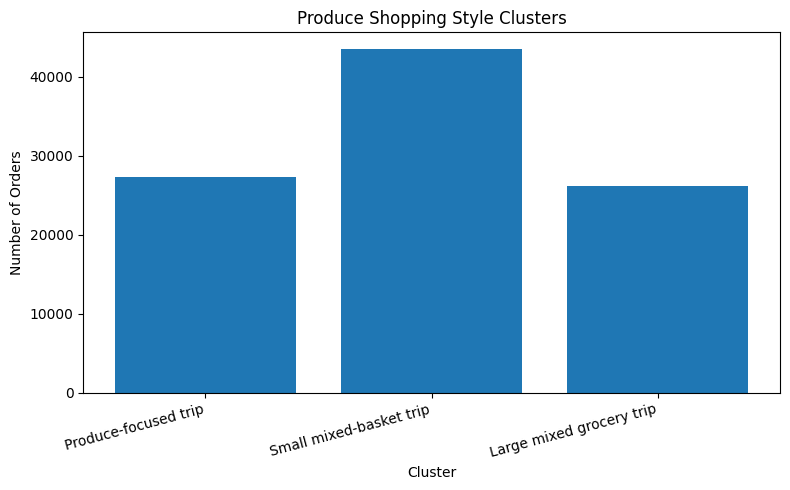

In [38]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

train_products_full = order_products_train.merge(
    products[["product_id", "department_id"]],
    on="product_id",
    how="left"
).merge(
    departments,
    on="department_id",
    how="left"
)

order_total_items = (
    train_products_full.groupby("order_id")["product_id"]
    .count()
    .reset_index(name="total_items_in_order")
)

order_department_counts = (
    train_products_full.groupby("order_id")["department"]
    .nunique()
    .reset_index(name="unique_departments")
)

produce_order_counts = (
    produce_orders.groupby("order_id")["product_id"]
    .count()
    .reset_index(name="produce_item_count")
)

produce_aisle_counts_order = (
    produce_orders.groupby("order_id")["aisle"]
    .nunique()
    .reset_index(name="unique_produce_aisles")
)

produce_order_features = (
    produce_order_counts
    .merge(order_total_items, on="order_id", how="left")
    .merge(order_department_counts, on="order_id", how="left")
    .merge(produce_aisle_counts_order, on="order_id", how="left")
)

produce_order_features["produce_share"] = (
    produce_order_features["produce_item_count"] /
    produce_order_features["total_items_in_order"]
).round(4)

print("Preview of Produce order features:")
display(produce_order_features.head())

cluster_features = [
    "produce_item_count",
    "total_items_in_order",
    "unique_departments",
    "unique_produce_aisles",
    "produce_share"
]

X = produce_order_features[cluster_features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
produce_order_features["cluster"] = kmeans.fit_predict(X_scaled)

cluster_summary = (
    produce_order_features.groupby("cluster")[cluster_features]
    .mean()
    .round(2)
    .reset_index()
)

cluster_sizes = (
    produce_order_features["cluster"]
    .value_counts()
    .sort_index()
    .reset_index()
)
cluster_sizes.columns = ["cluster", "order_count"]

cluster_summary = cluster_summary.merge(cluster_sizes, on="cluster", how="left")

cluster_summary["percentage_of_orders"] = (
    cluster_summary["order_count"] / cluster_summary["order_count"].sum() * 100
).round(2)

cluster_labels = {
    0: "Produce-focused trip",
    1: "Small mixed-basket trip",
    2: "Large mixed grocery trip"
}

produce_order_features["cluster_label"] = produce_order_features["cluster"].map(cluster_labels)
cluster_summary["cluster_label"] = cluster_summary["cluster"].map(cluster_labels)

print("Produce shopping style cluster summary:")
display(cluster_summary[
    [
        "cluster",
        "cluster_label",
        "produce_item_count",
        "total_items_in_order",
        "unique_departments",
        "unique_produce_aisles",
        "produce_share",
        "order_count",
        "percentage_of_orders"
    ]
])

plt.figure(figsize=(8, 5))
plt.bar(cluster_summary["cluster_label"], cluster_summary["order_count"])
plt.title("Produce Shopping Style Clusters")
plt.xlabel("Cluster")
plt.ylabel("Number of Orders")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

This extra-credit analysis used K-means clustering to group Produce-containing orders into different Produce shopping styles. I used features that describe basket behavior, including the number of Produce items, the total number of items in the order, the number of unique departments, the number of unique Produce aisles, and the share of Produce within the full basket. The clustering results revealed three main shopping styles. The first cluster represents Produce-focused trips, where Produce makes up the largest share of the basket. The second cluster represents small mixed-basket trips, where Produce appears in smaller amounts within a broader order. The third cluster represents large mixed grocery trips, where customers buy many items across many departments and also include a substantial amount of Produce. These findings are meaningful because they show that Produce does not serve only one shopping role. Instead, it appears in targeted Produce-heavy trips, smaller mixed trips, and large full-basket shopping trips.